In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = "Images/regular_01.jpg"

In [9]:
def compute_circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    if perimeter == 0:
        return 0

    circularity = 4 * np.pi * area / (perimeter ** 2)
    return circularity

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

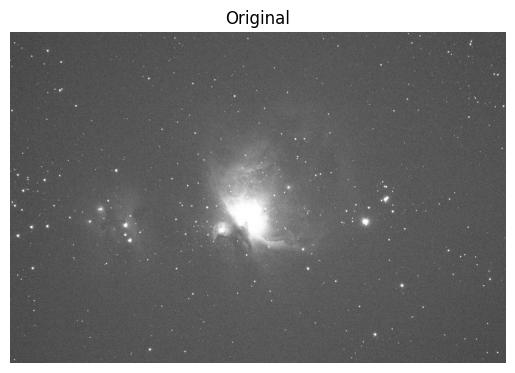

In [3]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

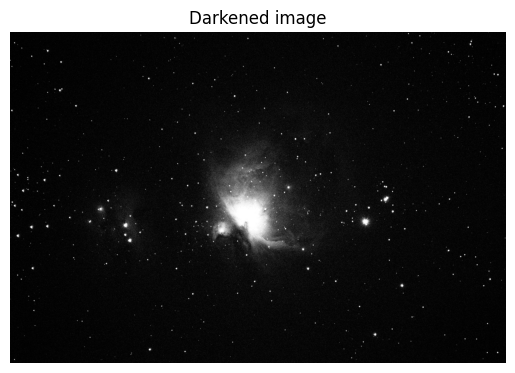

In [23]:
darkened = cv2.addWeighted(img, alpha=0.1, src2=np.zeros(img.shape, img.dtype), beta=0.3, gamma=-10)

plt.imshow(darkened, cmap="gray")
plt.title("Darkened image")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

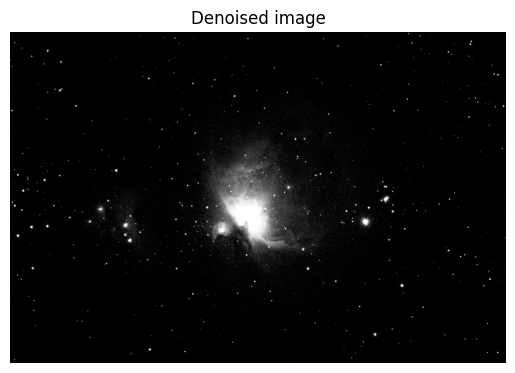

In [37]:
denoised = cv2.medianBlur(darkened, 5)
denoised = cv2.GaussianBlur(denoised, (5,5), 0)

plt.imshow(denoised, cmap="gray")
plt.title("Denoised image")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

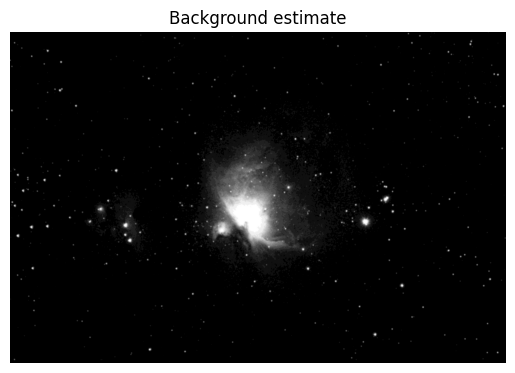

In [38]:
blur_large = cv2.GaussianBlur(denoised, (31,31), 0)

plt.imshow(blur_large, cmap="gray")
plt.title("Background estimate")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

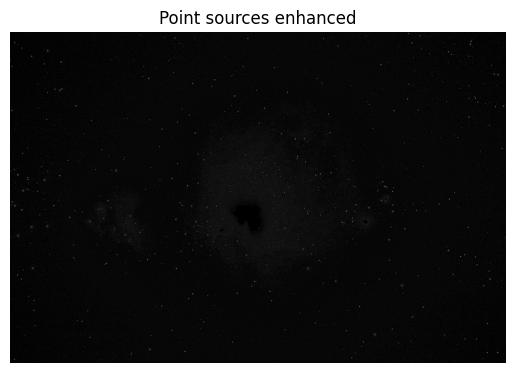

In [25]:
stars = cv2.subtract(darkened, blur_large)

plt.imshow(stars, cmap="gray")
plt.title("Point sources enhanced")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

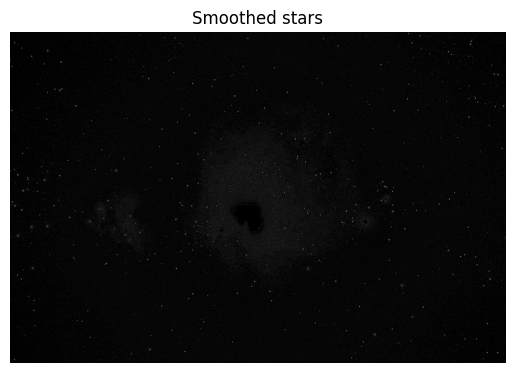

In [26]:
stars_blur = cv2.GaussianBlur(stars, (5,5), 0)

plt.imshow(stars_blur, cmap="gray")
plt.title("Smoothed stars")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

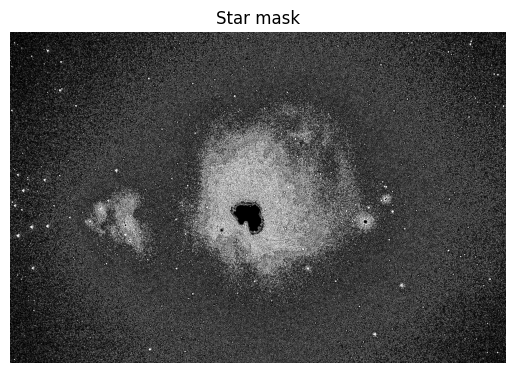

In [33]:
_, mask = cv2.threshold(
    stars_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(mask, cmap="gray")
plt.title("Star mask")
plt.axis("off")

In [34]:
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

valid = []

for c in contours:

    area = cv2.contourArea(c)

    if area < 3 or area > 120:
        continue

    circ = compute_circularity(c)

    if circ < 0.6:
        continue

    valid.append(c)

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

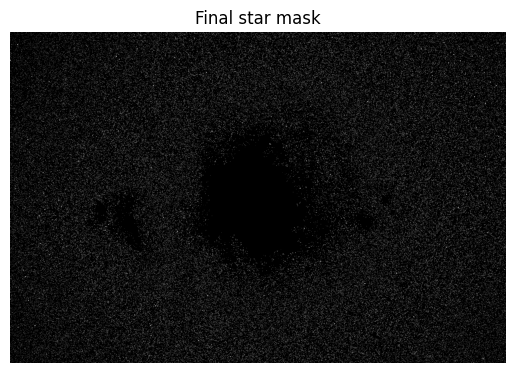

In [35]:
star_mask = np.zeros_like(mask)

cv2.drawContours(star_mask, valid, -1, 255, -1)

plt.imshow(star_mask, cmap="gray")
plt.title("Final star mask")
plt.axis("off")

(np.float64(-0.5), np.float64(6983.5), np.float64(4659.5), np.float64(-0.5))

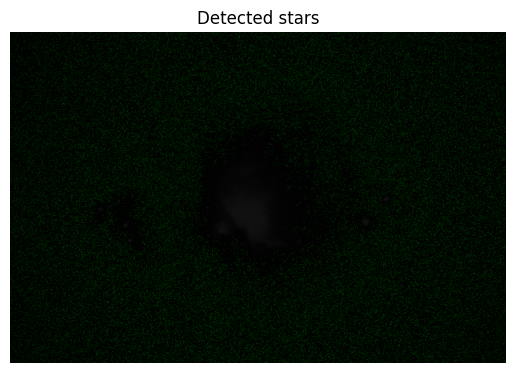

In [36]:
overlay = cv2.cvtColor(darkened, cv2.COLOR_GRAY2RGB)

cv2.drawContours(overlay, valid, -1, (0,255,0), 1)

plt.imshow(overlay)
plt.title("Detected stars")
plt.axis("off")